# Evaluacion Parcial 4: Analisis Exploratorio de Datos
**Asignatura:** ADY1100 — Preprocesamiento de Datos  
**Caso:** Banco Financiero Global — Prediccion de Depositos a Plazo  

**Objetivo:** Identificar las caracteristicas que distinguen a los clientes que contratan un deposito a plazo, para optimizar futuras campanas de marketing.

## 0. Carga y Configuracion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
os.makedirs('graficos', exist_ok=True)

df = pd.read_csv('bank-additional-full.csv', sep=';')
df = df.drop_duplicates()

# Descartar 'duration' por ser data leaker
if 'duration' in df.columns:
    df = df.drop(columns=['duration'])

rename_columns = {
    'y':'deposito_plazo','age':'edad','job':'trabajo','marital':'estado_civil',
    'education':'educacion','default':'mora','housing':'vivienda','loan':'prestamo',
    'contact':'contacto','month':'mes','day_of_week':'dia_semana','campaign':'campana',
    'pdays':'dias_previos','previous':'anterior','poutcome':'resultado_anterior',
    'emp.var.rate':'var_empleo','cons.price.idx':'indice_precios',
    'cons.conf.idx':'indice_confianza','euribor3m':'tasa_euribor','nr.employed':'num_empleados'
}
df = df.rename(columns=rename_columns)
df['deposito_plazo'] = df['deposito_plazo'].map({'yes':'si','no':'no'})
df['deposito_plazo_num'] = df['deposito_plazo'].map({'si':1,'no':0})

df['trabajo'] = df['trabajo'].replace({
    'admin.':'administrativo','blue-collar':'obrero','entrepreneur':'empresario',
    'housemaid':'empleada_hogar','management':'gerencia','retired':'jubilado',
    'self-employed':'independiente','services':'servicios','student':'estudiante',
    'technician':'tecnico','unemployed':'desempleado','unknown':'desconocido'
})
df['estado_civil'] = df['estado_civil'].replace({
    'married':'casado','single':'soltero','divorced':'divorciado','unknown':'desconocido'})
df['educacion'] = df['educacion'].replace({
    'basic.4y':'basica_4','basic.6y':'basica_6','basic.9y':'basica_9',
    'high.school':'media','illiterate':'analfabeto',
    'professional.course':'tecnico_prof','university.degree':'universitario','unknown':'desconocido'
})
df['mora'] = df['mora'].replace({'yes':'si','no':'no','unknown':'desconocido'})
df['vivienda'] = df['vivienda'].replace({'yes':'si','no':'no','unknown':'desconocido'})
df['prestamo'] = df['prestamo'].replace({'yes':'si','no':'no','unknown':'desconocido'})
df['contacto'] = df['contacto'].replace({'cellular':'celular','telephone':'telefono_fijo'})
df['resultado_anterior'] = df['resultado_anterior'].replace({
    'failure':'fracaso','success':'exito','nonexistent':'sin_contacto'})

print(f'Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print(f"Variable objetivo: {df['deposito_plazo'].value_counts().to_dict()}")

Dataset cargado: 41,176 filas x 21 columnas
Variable objetivo: {'no': 36537, 'si': 4639}


### Ranking de Variables Mas Relevantes

Antes de entrar al detalle grafico por grafico, calculamos que tan asociada esta cada variable con la variable objetivo (`deposito_plazo_num`). Para las variables numericas usamos correlacion de Pearson, y para las categoricas usamos **V de Cramer** (una medida de asociacion para variables categoricas, basada en el estadistico Chi-cuadrado). Esto nos da un primer panorama de que variables conviene priorizar en el analisis bivariado que sigue.

In [2]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('deposito_plazo_num')
cat_cols = df.select_dtypes(include=['object']).columns.drop('deposito_plazo')

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1),(rcorr-1)))

num_corrs = [(col, np.abs(df[col].corr(df['deposito_plazo_num']))) for col in numeric_cols]
cat_corrs = [(col, cramers_v(df[col], df['deposito_plazo_num'])) for col in cat_cols]
all_corrs = sorted(num_corrs + cat_corrs, key=lambda x: x[1], reverse=True)

print('Top 10 Variables mas relevantes:')
for i,(col,corr) in enumerate(all_corrs[:10]):
    print(f'  {i+1}. {col}: {corr:.4f}')

Top 10 Variables mas relevantes:
  1. num_empleados: 0.3547
  2. dias_previos: 0.3249
  3. resultado_anterior: 0.3204
  4. tasa_euribor: 0.3077
  5. var_empleo: 0.2983
  6. mes: 0.2741
  7. anterior: 0.2302
  8. trabajo: 0.1520
  9. contacto: 0.1446
  10. indice_precios: 0.1361


## 1. Analisis Univariado

Exploracion de cada variable de forma individual. Esta fase es esencial para comprender la estructura fundamental de los datos antes de aplicar cualquier modelo predictivo. Al aislar cada variable, es posible detectar tempranamente distribuciones asimétricas, identificar valores atípicos severos o descubrir desbalanceos de clases significativos (como ocurre frecuentemente con la variable objetivo en problemas de conversión). Detectar estas características desde un principio determina las técnicas correctivas que se aplicarán posteriormente en la etapa de preprocesamiento.

**Variables del dataset (resumen visual):**


### Grafico 1: Variable Objetivo — Desbalanceo de Clases

Este gráfico permite visualizar la proporción de clientes que contrataron el depósito frente a los que no. Identificar este desbalance es crucial, ya que los modelos predictivos tienden a sesgarse hacia la clase mayoritaria si no se toman medidas.


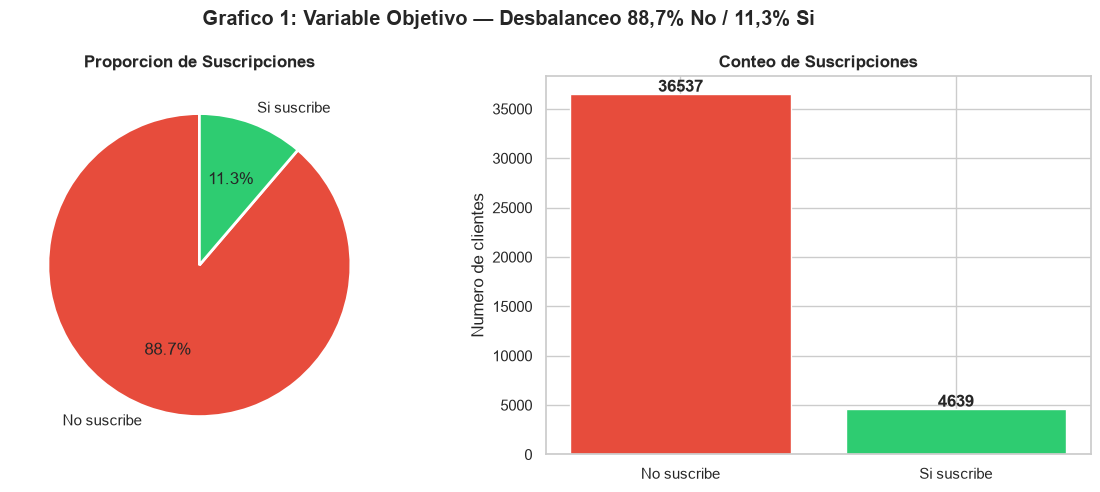

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
conteo = df['deposito_plazo'].value_counts()
colores = ['#e74c3c','#2ecc71']
axes[0].pie(conteo.values, labels=['No suscribe','Si suscribe'],
            autopct='%1.1f%%', colors=colores, startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Proporcion de Suscripciones', fontweight='bold')
axes[1].bar(['No suscribe','Si suscribe'], conteo.values, color=colores, edgecolor='white')
for i, val in enumerate(conteo.values):
    axes[1].text(i, val+200, str(val), ha='center', fontweight='bold')
axes[1].set_ylabel('Numero de clientes')
axes[1].set_title('Conteo de Suscripciones', fontweight='bold')
plt.suptitle('Grafico 1: Variable Objetivo — Desbalanceo 88,7% No / 11,3% Si', fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/univariado_variable_objetivo.png', bbox_inches='tight', dpi=150)
plt.show()

### Grafico 2: Edad — Distribucion Univariada

Se analiza la distribución de la edad de los clientes para identificar en qué rangos se concentra el público objetivo del banco y detectar posibles valores atípicos (personas de edades inusualmente altas).


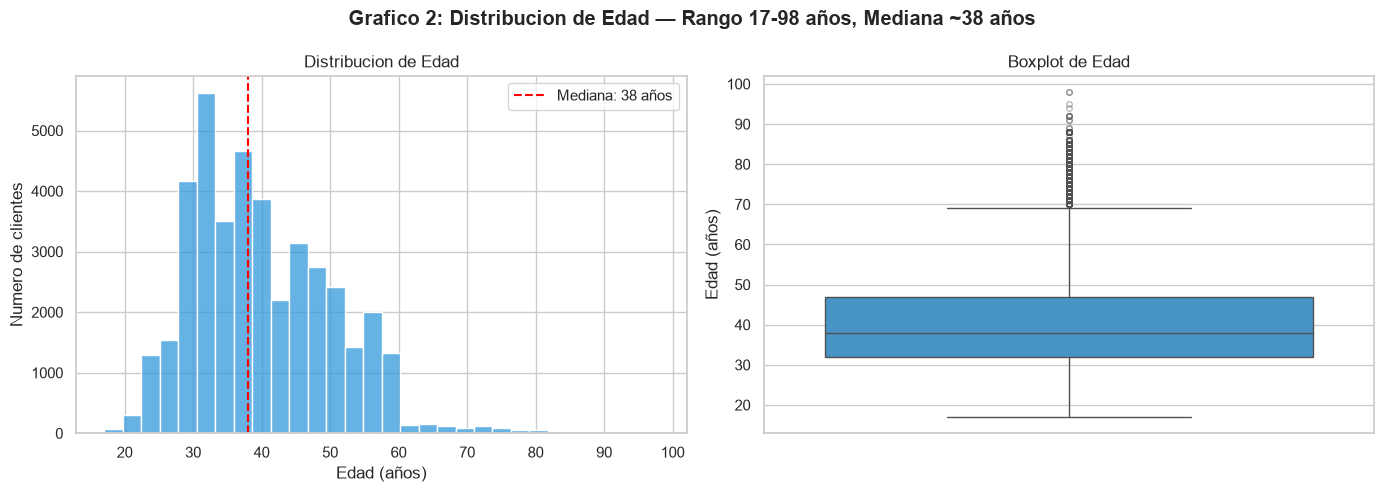

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x='edad', bins=30, color='#3498db', ax=axes[0], edgecolor='white')
axes[0].set_xlabel('Edad (años)')
axes[0].set_ylabel('Numero de clientes')
axes[0].set_title('Distribucion de Edad')
axes[0].axvline(df['edad'].median(), color='red', linestyle='--',
                label=f"Mediana: {df['edad'].median():.0f} años")
axes[0].legend()
sns.boxplot(y=df['edad'], ax=axes[1], color='#3498db',
            flierprops=dict(marker='o', markersize=4, alpha=0.4))
axes[1].set_ylabel('Edad (años)')
axes[1].set_title('Boxplot de Edad')
plt.suptitle('Grafico 2: Distribucion de Edad — Rango 17-98 años, Mediana ~38 años', fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/univariado_edad.png', bbox_inches='tight', dpi=150)
plt.show()

### Grafico 3: Tipo de Trabajo — Distribucion

Explorar los sectores laborales nos ayuda a entender el perfil socioeconómico predominante en la base de datos, lo cual puede influir fuertemente en la capacidad de ahorro o inversión del cliente.


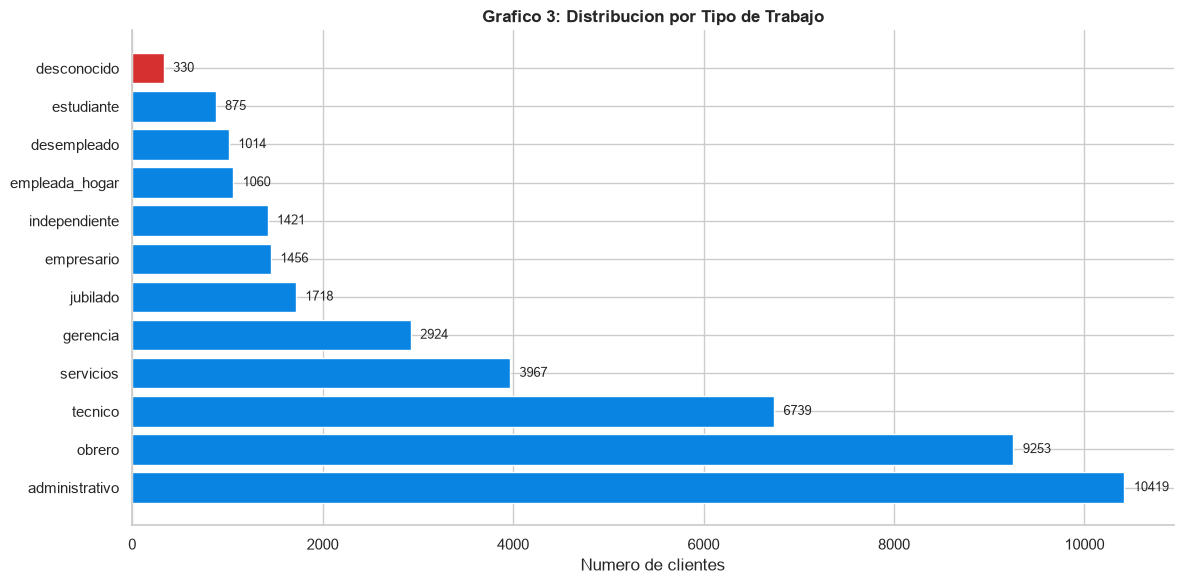

In [5]:
conteo_trabajo = df['trabajo'].value_counts()
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(conteo_trabajo.index, conteo_trabajo.values,
               color=['#d63031' if x=='desconocido' else '#0984e3' for x in conteo_trabajo.index], edgecolor='white')
for bar, val in zip(bars, conteo_trabajo.values):
    ax.text(bar.get_width()+100, bar.get_y()+bar.get_height()/2,
            str(val), va='center', fontsize=9)
ax.set_xlabel('Numero de clientes')
ax.set_title('Grafico 3: Distribucion por Tipo de Trabajo', fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig('graficos/univariado_trabajo.png', bbox_inches='tight', dpi=150)
plt.show()

### Grafico 4: Estado Civil — Distribucion

Muestra la composición de la cartera de clientes según su estado civil, una variable demográfica básica que puede correlacionar con las obligaciones financieras de la persona.


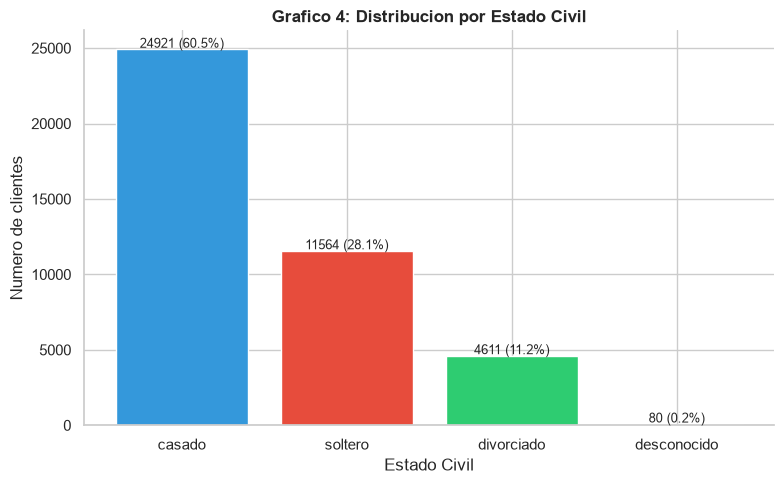

In [6]:
ec = df['estado_civil'].value_counts()
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(ec.index, ec.values, color=['#3498db','#e74c3c','#2ecc71','#95a5a6'], edgecolor='white')
for i, (lbl, val) in enumerate(zip(ec.index, ec.values)):
    pct = val/len(df)*100
    ax.text(i, val+100, str(val)+' ('+str(round(pct,1))+'%)', ha='center', fontsize=9)
ax.set_xlabel('Estado Civil')
ax.set_ylabel('Numero de clientes')
ax.set_title('Grafico 4: Distribucion por Estado Civil', fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig('graficos/univariado_estado_civil.png', bbox_inches='tight', dpi=150)
plt.show()

### Grafico 5: Nivel de Educacion — Distribucion

Visualiza el grado de formación académica de los clientes. Al tener un orden jerárquico natural, esta variable nos da pistas sobre el nivel de ingresos potenciales.


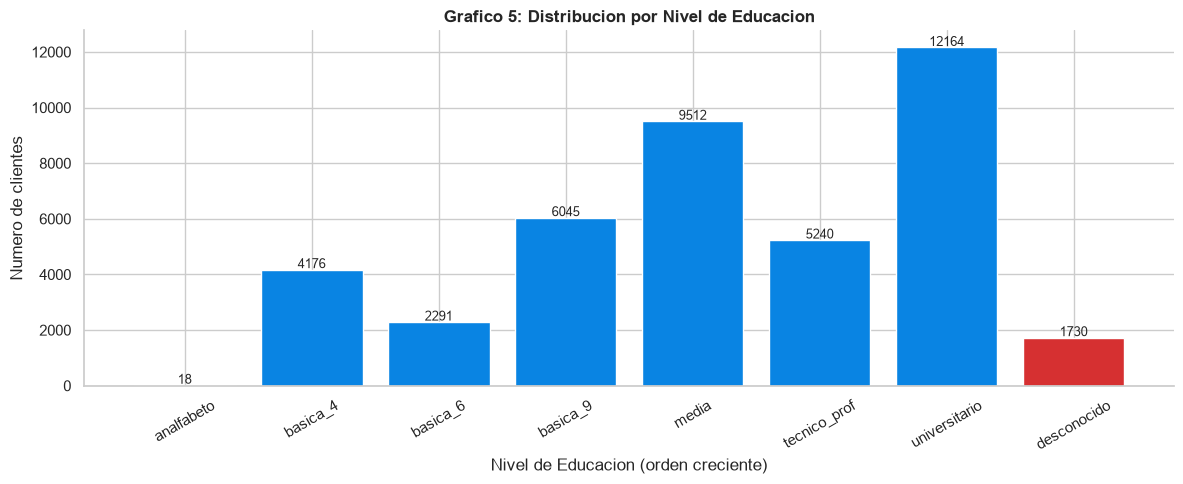

In [7]:
orden_edu = ['analfabeto','basica_4','basica_6','basica_9','media','tecnico_prof','universitario','desconocido']
edu_counts = df['educacion'].value_counts().reindex(orden_edu).dropna()
fig, ax = plt.subplots(figsize=(12, 5))
colores_edu = ['#d63031' if x=='desconocido' else '#0984e3' for x in edu_counts.index]
bars = ax.bar(edu_counts.index, edu_counts.values, color=colores_edu, edgecolor='white')
for bar, val in zip(bars, edu_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
            str(val), ha='center', fontsize=9)
ax.set_xlabel('Nivel de Educacion (orden creciente)')
ax.set_ylabel('Numero de clientes')
ax.set_title('Grafico 5: Distribucion por Nivel de Educacion', fontweight='bold')
ax.tick_params(axis='x', rotation=30)
sns.despine()
plt.tight_layout()
plt.savefig('graficos/univariado_educacion.png', bbox_inches='tight', dpi=150)
plt.show()

### Grafico 6: Numero de Contactos en Campana — Valores Extremos

Observar la cantidad de llamadas realizadas a un mismo cliente durante esta campaña es clave para identificar valores extremos que podrían indicar insistencia excesiva o errores de registro.


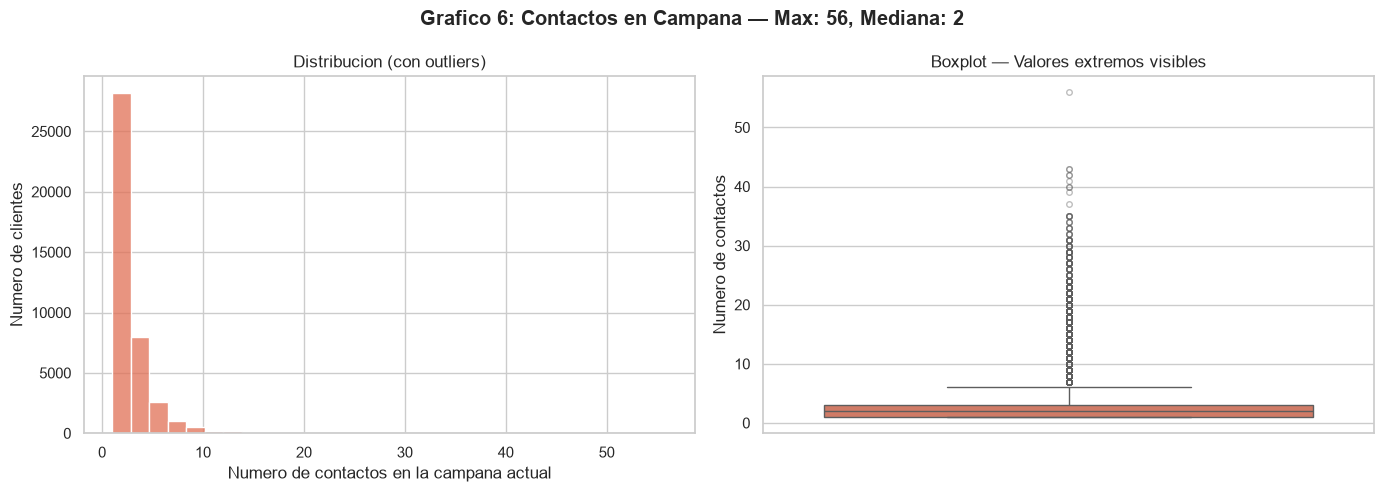

Percentil 95: 7 contactos | Valores > 10: 869 (2.1%)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x='campana', bins=30, color='#e17055', ax=axes[0], edgecolor='white')
axes[0].set_xlabel('Numero de contactos en la campana actual')
axes[0].set_ylabel('Numero de clientes')
axes[0].set_title('Distribucion (con outliers)')
sns.boxplot(y=df['campana'], ax=axes[1], color='#e17055',
            flierprops=dict(marker='o', markersize=4, alpha=0.4))
axes[1].set_ylabel('Numero de contactos')
axes[1].set_title('Boxplot — Valores extremos visibles')
max_c = df['campana'].max()
med_c = int(df['campana'].median())
plt.suptitle('Grafico 6: Contactos en Campana — Max: '+str(max_c)+', Mediana: '+str(med_c), fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/univariado_campana_contactos.png', bbox_inches='tight', dpi=150)
plt.show()
p95 = df['campana'].quantile(0.95)
n_extremos = (df['campana']>10).sum()
print(f'Percentil 95: {p95:.0f} contactos | Valores > 10: {n_extremos} ({n_extremos/len(df)*100:.1f}%)')

### Grafico 7: Tasa Euribor 3 Meses — Variable Macroeconomica

La tasa Euribor refleja el contexto económico general (costo del dinero). Su distribución nos permite saber si la campaña se realizó en un momento de tasas altas o bajas.


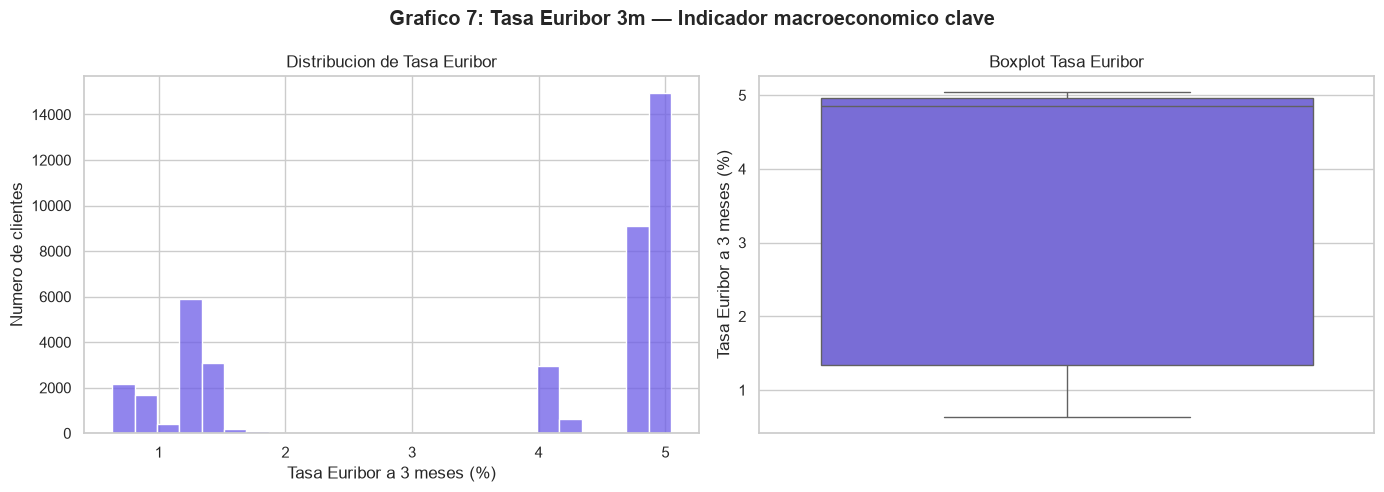

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x='tasa_euribor', bins=25, color='#6c5ce7', ax=axes[0], edgecolor='white')
axes[0].set_xlabel('Tasa Euribor a 3 meses (%)')
axes[0].set_ylabel('Numero de clientes')
axes[0].set_title('Distribucion de Tasa Euribor')
sns.boxplot(y=df['tasa_euribor'], ax=axes[1], color='#6c5ce7',
            flierprops=dict(marker='o', markersize=4, alpha=0.4))
axes[1].set_ylabel('Tasa Euribor a 3 meses (%)')
axes[1].set_title('Boxplot Tasa Euribor')
plt.suptitle('Grafico 7: Tasa Euribor 3m — Indicador macroeconomico clave', fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/univariado_tasa_euribor.png', bbox_inches='tight', dpi=150)
plt.show()

### Grafico 8: Variables Macroeconomicas — Panel Completo

Un vistazo general al resto de indicadores económicos (empleo, precios, confianza) para comprender la salud macroeconómica durante el periodo de contacto.


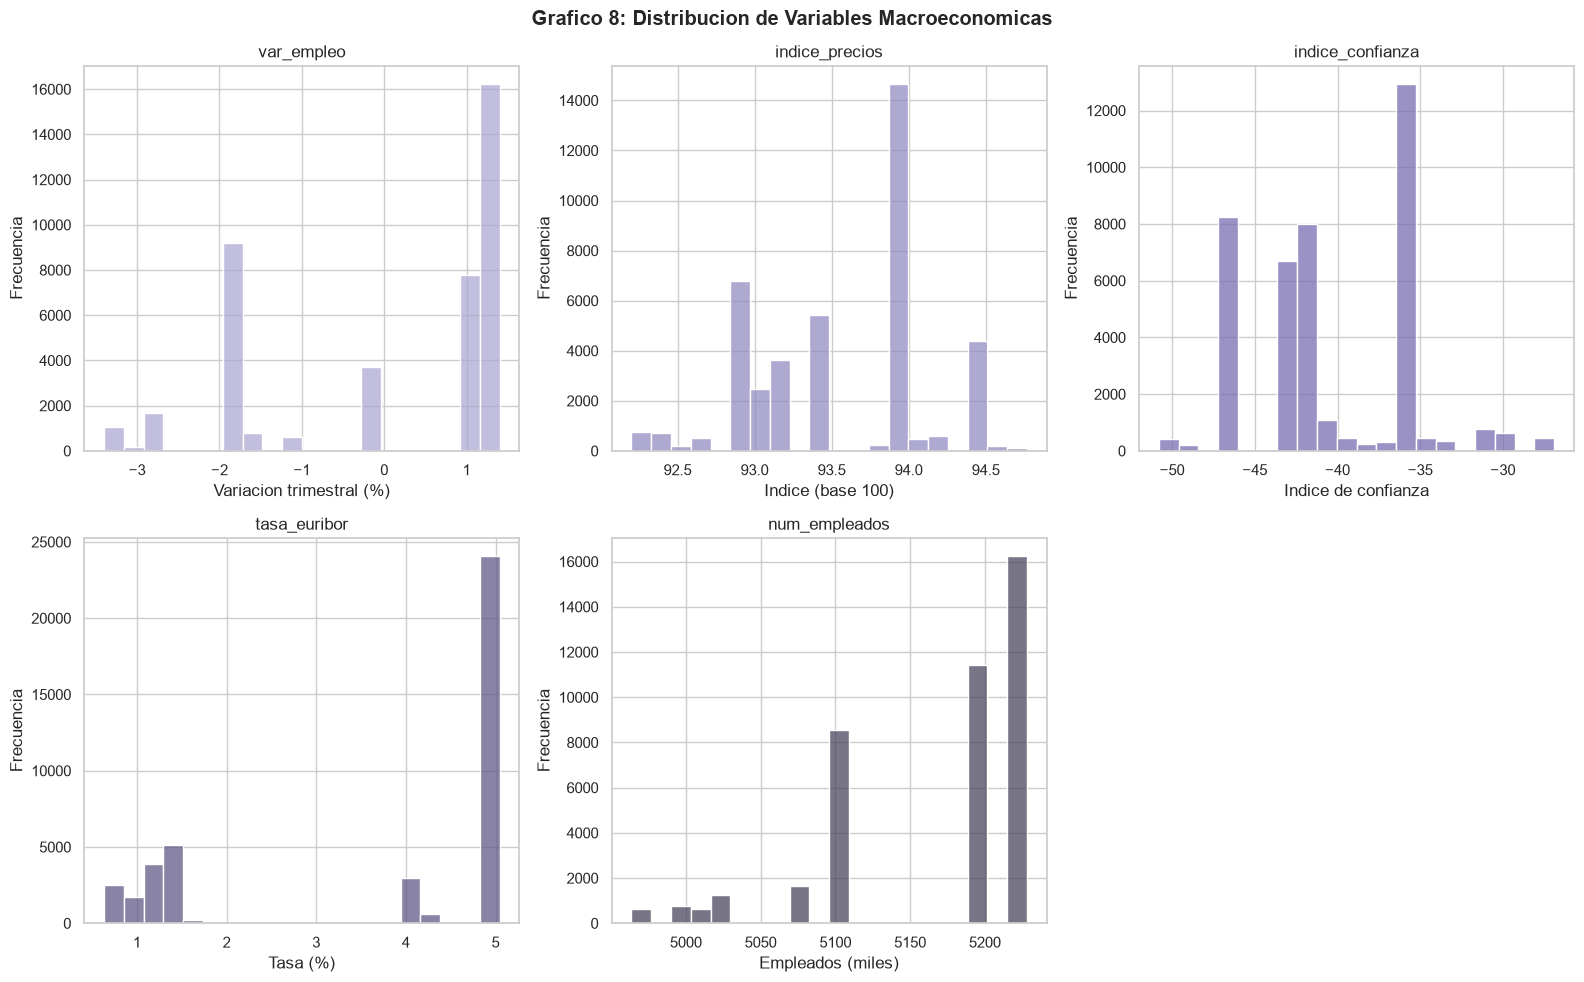

In [10]:
macro_cols = ['var_empleo','indice_precios','indice_confianza','tasa_euribor','num_empleados']
unidades = ['Variacion trimestral (%)','Indice (base 100)','Indice de confianza','Tasa (%)','Empleados (miles)']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, (col, unidad) in enumerate(zip(macro_cols, unidades)):
    sns.histplot(data=df, x=col, bins=20, color=sns.color_palette('Purples_d',5)[i],
                 ax=axes[i], edgecolor='white')
    axes[i].set_xlabel(unidad)
    axes[i].set_ylabel('Frecuencia')
    axes[i].set_title(col)
axes[5].axis('off')
plt.suptitle('Grafico 8: Distribucion de Variables Macroeconomicas', fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/univariado_variables_macroeconomicas.png', bbox_inches='tight', dpi=150)
plt.show()

### Grafico 9: Mes de Contacto — Volumen de Llamadas

Identificar los meses con mayor volumen de contactos ayuda a detectar posibles estacionalidades o meses de alta intensidad operativa por parte del banco.


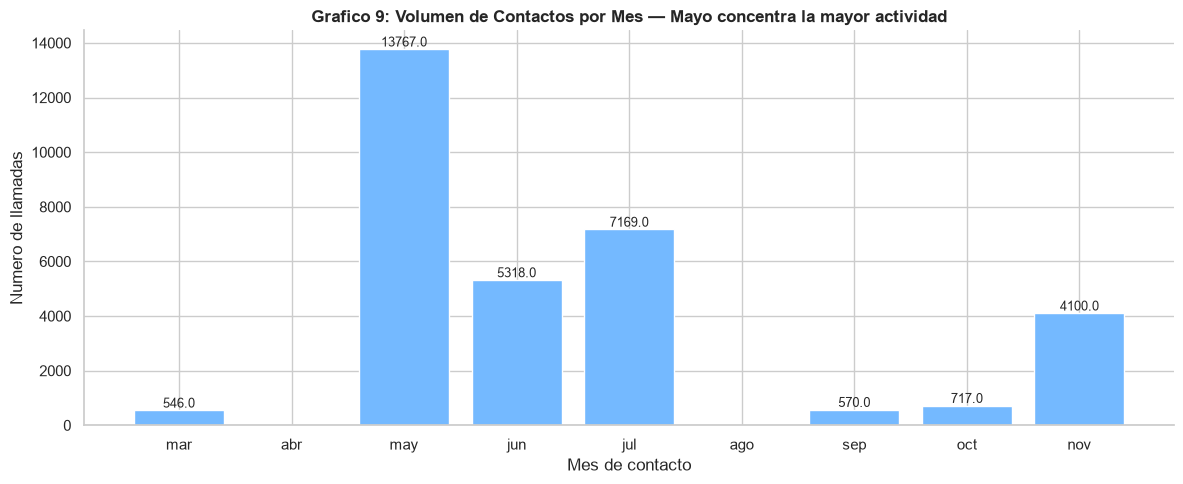

In [11]:
order_months = ['mar','abr','may','jun','jul','ago','sep','oct','nov','dic']
conteo_mes = df['mes'].value_counts().reindex(order_months)
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(conteo_mes.index, conteo_mes.values, color='#74b9ff', edgecolor='white')
for i, val in enumerate(conteo_mes.values):
    ax.text(i, val+100, str(val), ha='center', fontsize=9)
ax.set_xlabel('Mes de contacto')
ax.set_ylabel('Numero de llamadas')
ax.set_title('Grafico 9: Volumen de Contactos por Mes — Mayo concentra la mayor actividad', fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig('graficos/univariado_mes_volumen.png', bbox_inches='tight', dpi=150)
plt.show()

### Grafico 10: Resultado de Campana Anterior

Este gráfico muestra qué tan exitosas (o no) fueron las interacciones pasadas con estos mismos clientes, un factor que suele condicionar fuertemente el éxito futuro.


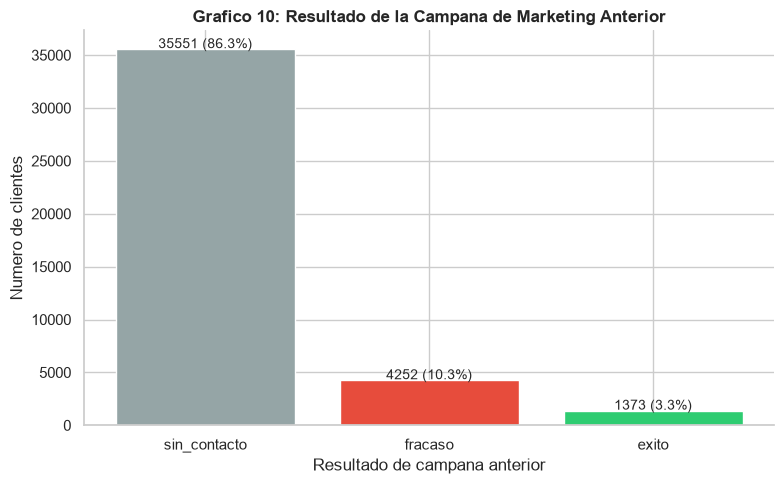

In [12]:
ra = df['resultado_anterior'].value_counts()
colores_ra = {'sin_contacto':'#95a5a6','fracaso':'#e74c3c','exito':'#2ecc71'}
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(ra.index, ra.values,
              color=[colores_ra.get(x,'#3498db') for x in ra.index], edgecolor='white')
for bar, val in zip(bars, ra.values):
    pct = val/len(df)*100
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
            str(val)+' ('+str(round(pct,1))+'%)', ha='center', fontsize=10)
ax.set_xlabel('Resultado de campana anterior')
ax.set_ylabel('Numero de clientes')
ax.set_title('Grafico 10: Resultado de la Campana de Marketing Anterior', fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig('graficos/univariado_resultado_anterior.png', bbox_inches='tight', dpi=150)
plt.show()

## 2. Analisis Bivariado

Relacion de cada variable independiente con la variable objetivo `deposito_plazo`. El propósito de cruzar sistemáticamente cada característica contra la métrica de éxito (tasa de conversión o frecuencia relativa) es discriminar rápidamente cuáles atributos poseen verdadero poder predictivo. Las variables que muestran cambios drásticos en la conversión a través de sus distintas categorías o valores numéricos aportarán gran valor al algoritmo, mientras que aquellas que presentan un comportamiento plano se consideran ruido estadístico y pueden ser descartadas.


### Grafico 11: Correlacion de Todas las Variables con la Variable Objetivo

Este panel general resume la fuerza de asociación lineal entre todas las variables y el éxito de la campaña, sirviendo como mapa inicial para detectar los mejores predictores.


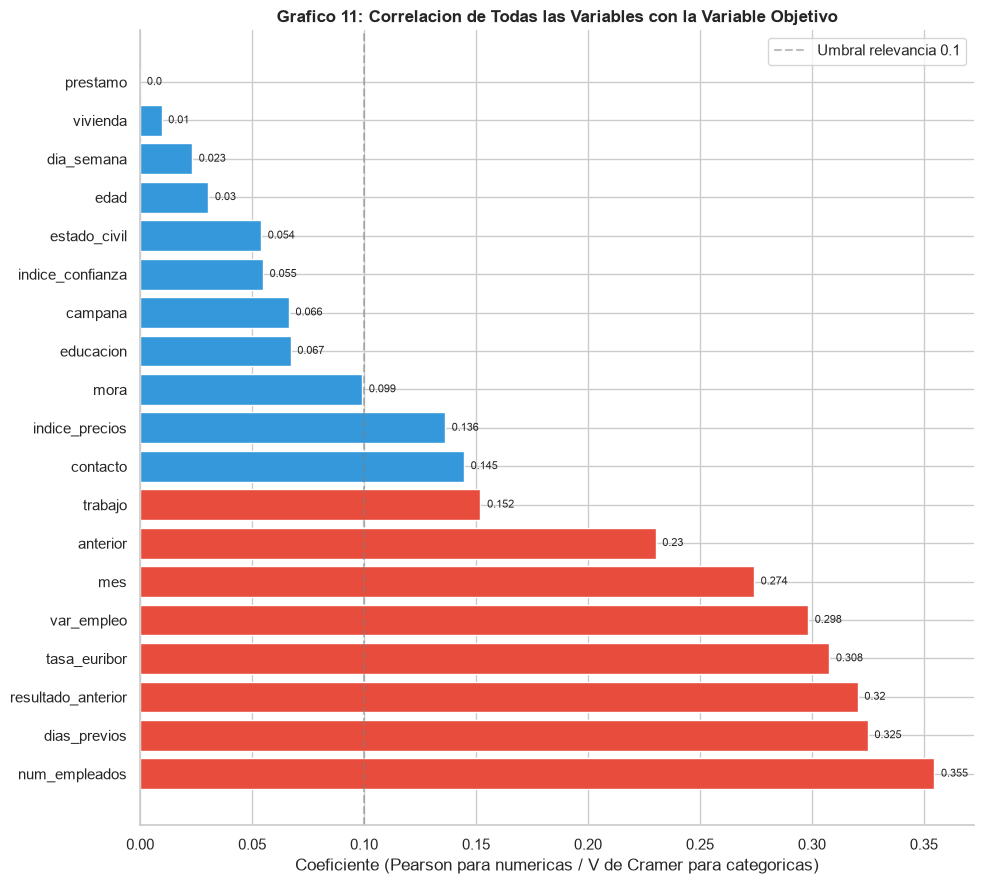

In [13]:
corrs_df = pd.DataFrame(all_corrs, columns=['Variable','Correlacion'])
fig, ax = plt.subplots(figsize=(10, 9))
colores_corr = ['#e74c3c' if v>0.15 else '#3498db' for v in corrs_df['Correlacion']]
bars = ax.barh(corrs_df['Variable'], corrs_df['Correlacion'], color=colores_corr, edgecolor='white')
for bar, val in zip(bars, corrs_df['Correlacion']):
    ax.text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2,
            str(round(val,3)), va='center', fontsize=8)
ax.axvline(0.1, color='gray', linestyle='--', alpha=0.5, label='Umbral relevancia 0.1')
ax.set_xlabel('Coeficiente (Pearson para numericas / V de Cramer para categoricas)')
ax.set_title('Grafico 11: Correlacion de Todas las Variables con la Variable Objetivo', fontweight='bold')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('graficos/bivariado_correlacion_todas_variables.png', bbox_inches='tight', dpi=150)
plt.show()

### Grafico 12: Edad vs Tasa de Conversion — Jubilados destacan

Al cruzar la edad con la tasa de conversión, descubrimos comportamientos no lineales; por ejemplo, que los clientes mayores o jubilados tienen mucha más propensión a contratar el depósito.


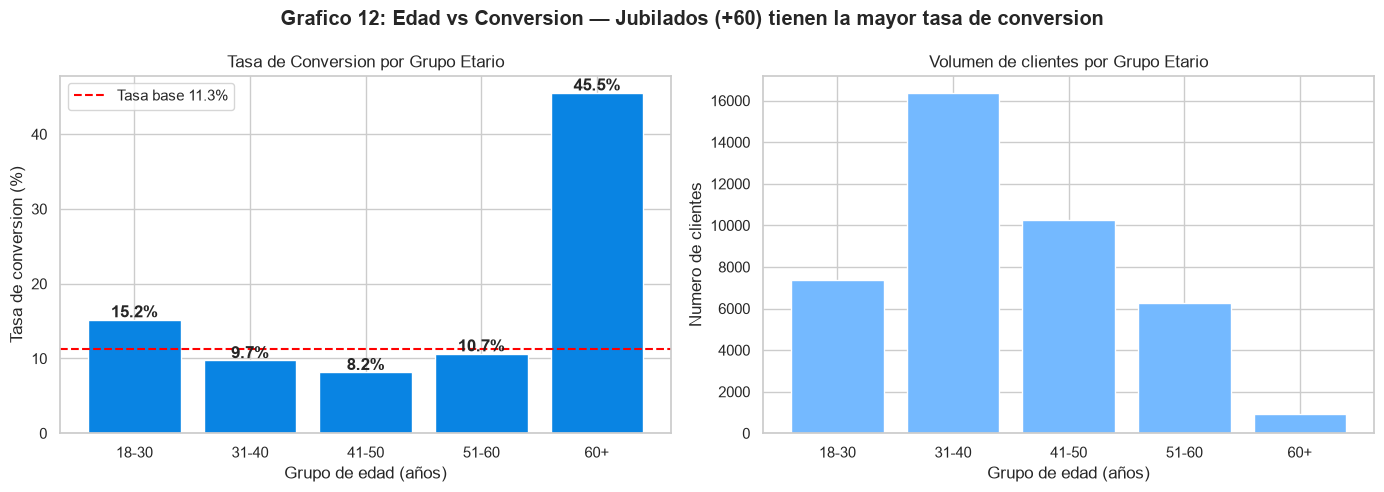

In [14]:
bins_edad = [17,30,40,50,60,100]
labels_edad = ['18-30','31-40','41-50','51-60','60+']
df['grupo_edad'] = pd.cut(df['edad'], bins=bins_edad, labels=labels_edad, right=True)
conv_edad = df.groupby('grupo_edad', observed=True)['deposito_plazo_num'].mean()*100
conteo_edad = df.groupby('grupo_edad', observed=True)['deposito_plazo_num'].count()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(conv_edad.index.astype(str), conv_edad.values, color='#0984e3', edgecolor='white')
for i, val in enumerate(conv_edad.values):
    axes[0].text(i, val+0.3, str(round(val,1))+'%', ha='center', fontweight='bold')
tasa_base = df['deposito_plazo_num'].mean()*100
axes[0].axhline(tasa_base, color='red', linestyle='--', label='Tasa base '+str(round(tasa_base,1))+'%')
axes[0].set_xlabel('Grupo de edad (años)')
axes[0].set_ylabel('Tasa de conversion (%)')
axes[0].set_title('Tasa de Conversion por Grupo Etario')
axes[0].legend()
axes[1].bar(conteo_edad.index.astype(str), conteo_edad.values, color='#74b9ff', edgecolor='white')
axes[1].set_xlabel('Grupo de edad (años)')
axes[1].set_ylabel('Numero de clientes')
axes[1].set_title('Volumen de clientes por Grupo Etario')
plt.suptitle('Grafico 12: Edad vs Conversion — Jubilados (+60) tienen la mayor tasa de conversion', fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/bivariado_edad_conversion.png', bbox_inches='tight', dpi=150)
plt.show()

### Grafico 13: Tipo de Trabajo vs Tasa de Conversion

Permite identificar qué profesiones o sectores laborales son más receptivos a la oferta del banco (ej. estudiantes o jubilados vs. obreros).


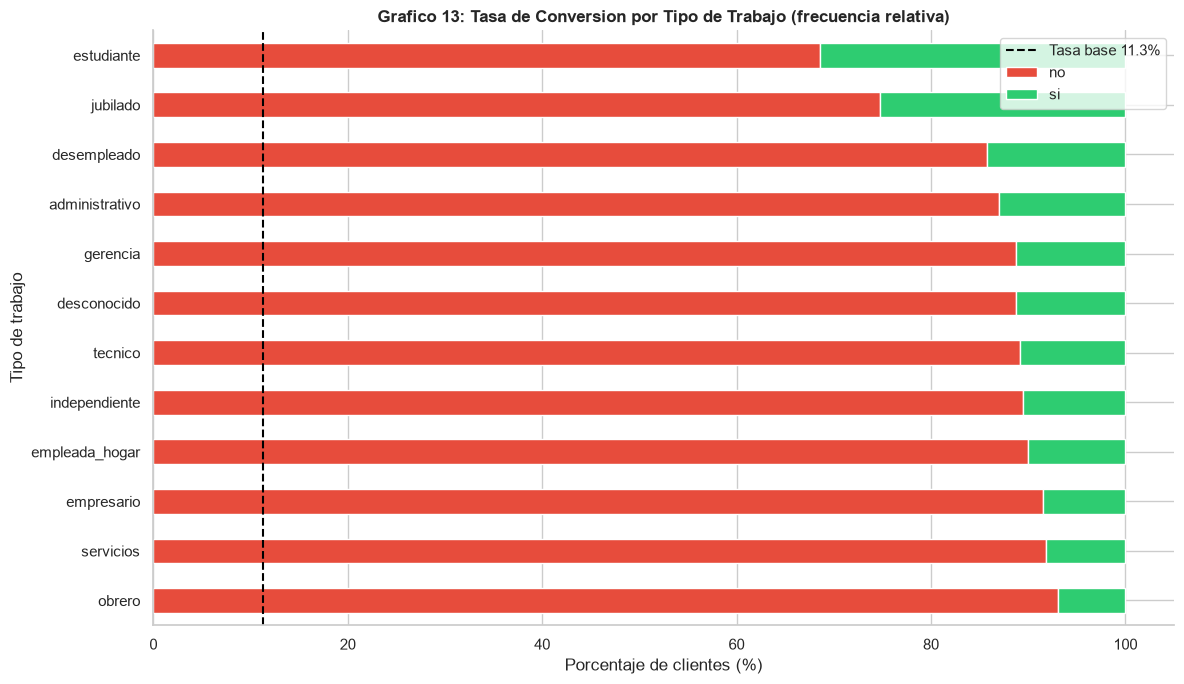

In [15]:
job_res = pd.crosstab(df['trabajo'], df['deposito_plazo'], normalize='index')*100
job_res = job_res.sort_values('si')
fig, ax = plt.subplots(figsize=(12, 7))
job_res.plot(kind='barh', stacked=True, color=['#e74c3c','#2ecc71'], ax=ax, edgecolor='white')
tasa_base = df['deposito_plazo_num'].mean()*100
ax.axvline(tasa_base, color='black', linestyle='--', linewidth=1.5,
           label='Tasa base '+str(round(tasa_base,1))+'%')
ax.set_xlabel('Porcentaje de clientes (%)')
ax.set_ylabel('Tipo de trabajo')
ax.set_title('Grafico 13: Tasa de Conversion por Tipo de Trabajo (frecuencia relativa)', fontweight='bold')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('graficos/bivariado_trabajo_conversion.png', bbox_inches='tight', dpi=150)
plt.show()

### Grafico 14: Educacion vs Tasa de Conversion

Muestra cómo el nivel educativo impacta la probabilidad de contratación, revelando si los clientes con mayor educación formal son mejores prospectos.


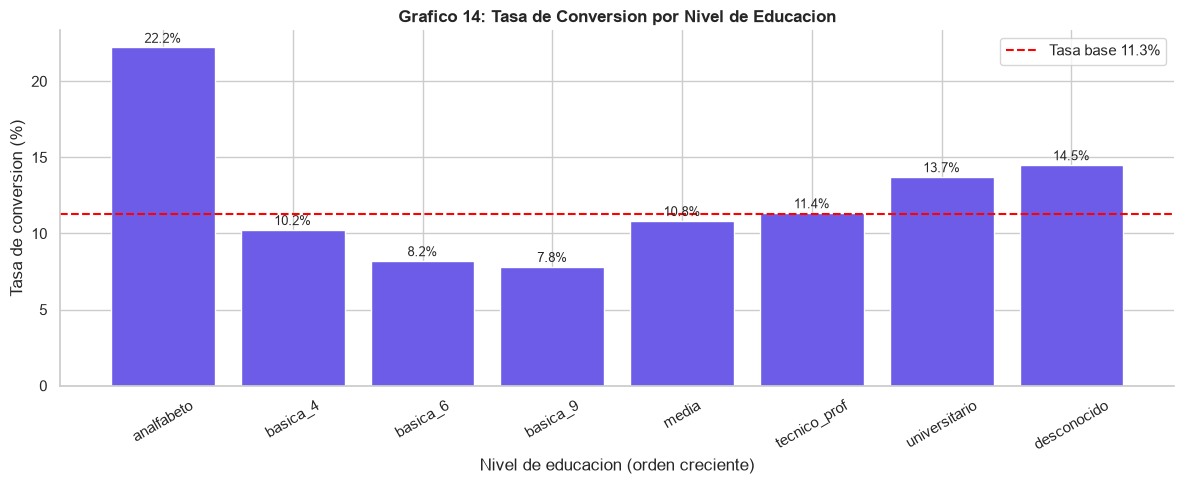

In [16]:
orden_edu = ['analfabeto','basica_4','basica_6','basica_9','media','tecnico_prof','universitario','desconocido']
edu_conv = df.groupby('educacion')['deposito_plazo_num'].mean()*100
edu_conv = edu_conv.reindex(orden_edu).dropna()
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(edu_conv.index, edu_conv.values, color='#6c5ce7', edgecolor='white')
for bar, val in zip(bars, edu_conv.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            str(round(val,1))+'%', ha='center', fontsize=9)
tasa_base = df['deposito_plazo_num'].mean()*100
ax.axhline(tasa_base, color='red', linestyle='--', label='Tasa base '+str(round(tasa_base,1))+'%')
ax.set_xlabel('Nivel de educacion (orden creciente)')
ax.set_ylabel('Tasa de conversion (%)')
ax.set_title('Grafico 14: Tasa de Conversion por Nivel de Educacion', fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('graficos/bivariado_educacion_conversion.png', bbox_inches='tight', dpi=150)
plt.show()

### Grafico 15: Canal de Contacto vs Conversion (Relativa vs Absoluta)

Compara la efectividad de los distintos medios de comunicación (celular vs teléfono fijo), lo cual es vital para optimizar los recursos logísticos de futuras campañas.


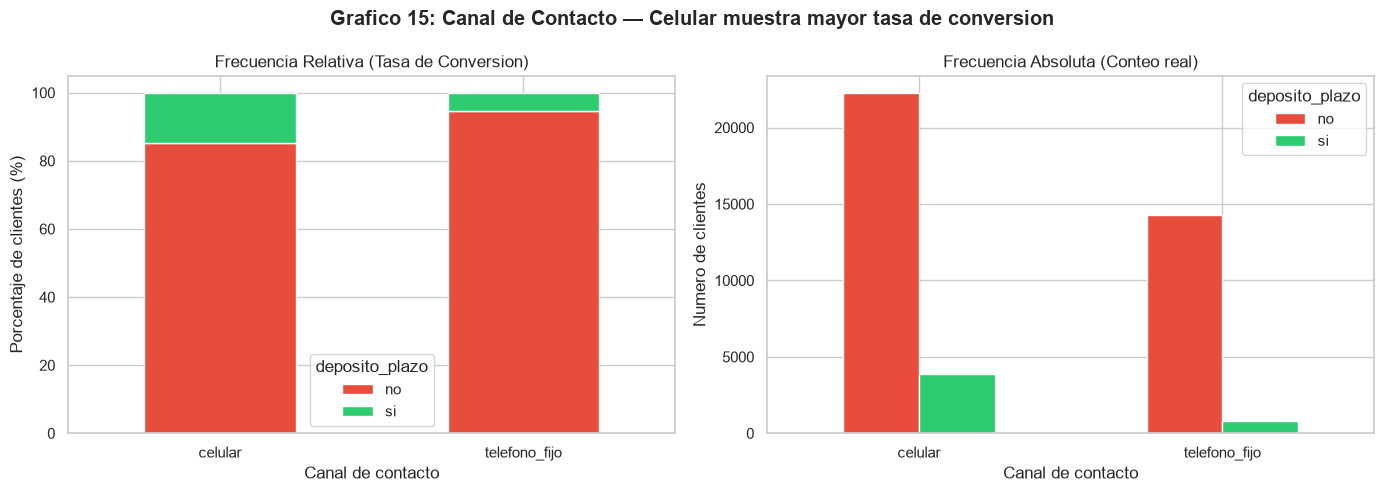

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
contact_rel = pd.crosstab(df['contacto'], df['deposito_plazo'], normalize='index')*100
contact_rel.plot(kind='bar', stacked=True, color=['#e74c3c','#2ecc71'], ax=axes[0], edgecolor='white')
axes[0].set_xlabel('Canal de contacto')
axes[0].set_ylabel('Porcentaje de clientes (%)')
axes[0].set_title('Frecuencia Relativa (Tasa de Conversion)')
axes[0].tick_params(axis='x', rotation=0)
contact_abs = pd.crosstab(df['contacto'], df['deposito_plazo'])
contact_abs.plot(kind='bar', color=['#e74c3c','#2ecc71'], ax=axes[1], edgecolor='white')
axes[1].set_xlabel('Canal de contacto')
axes[1].set_ylabel('Numero de clientes')
axes[1].set_title('Frecuencia Absoluta (Conteo real)')
axes[1].tick_params(axis='x', rotation=0)
plt.suptitle('Grafico 15: Canal de Contacto — Celular muestra mayor tasa de conversion', fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/bivariado_contacto_conversion.png', bbox_inches='tight', dpi=150)
plt.show()

### Grafico 16: Resultado Campana Anterior vs Conversion

Demuestra empíricamente que haber tenido éxito con un cliente en el pasado incrementa exponencialmente las probabilidades de que vuelva a aceptar una oferta financiera.


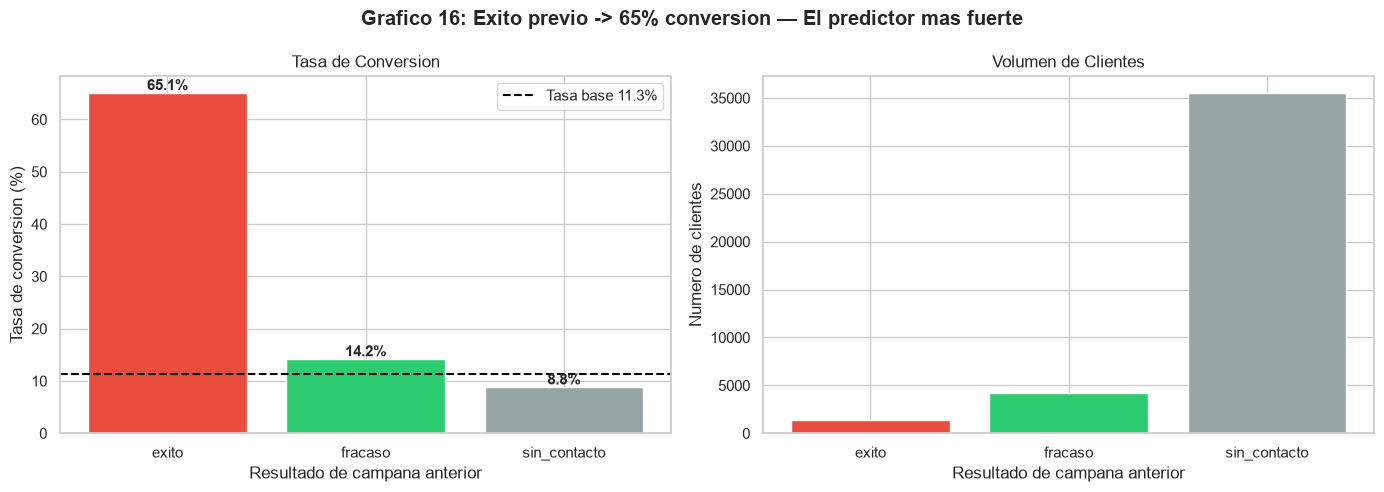

In [18]:
ra_conv = df.groupby('resultado_anterior')['deposito_plazo_num'].mean()*100
ra_count = df.groupby('resultado_anterior')['deposito_plazo_num'].count()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colores_ra = ['#e74c3c','#2ecc71','#95a5a6']
axes[0].bar(ra_conv.index, ra_conv.values, color=colores_ra, edgecolor='white')
for i, val in enumerate(ra_conv.values):
    axes[0].text(i, val+0.5, str(round(val,1))+'%', ha='center', fontweight='bold', fontsize=11)
tasa_base = df['deposito_plazo_num'].mean()*100
axes[0].axhline(tasa_base, color='black', linestyle='--',
                label='Tasa base '+str(round(tasa_base,1))+'%')
axes[0].set_xlabel('Resultado de campana anterior')
axes[0].set_ylabel('Tasa de conversion (%)')
axes[0].set_title('Tasa de Conversion')
axes[0].legend()
axes[1].bar(ra_count.index, ra_count.values, color=colores_ra, edgecolor='white')
axes[1].set_xlabel('Resultado de campana anterior')
axes[1].set_ylabel('Numero de clientes')
axes[1].set_title('Volumen de Clientes')
plt.suptitle('Grafico 16: Exito previo -> 65% conversion — El predictor mas fuerte', fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/bivariado_resultado_anterior_conversion.png', bbox_inches='tight', dpi=150)
plt.show()

### Grafico 17: Mes de Contacto vs Conversion (Volumen vs Tasa)

Analiza la efectividad real por mes, revelando que los meses con más llamadas no necesariamente son los meses con la mejor tasa de conversión (calidad vs cantidad).


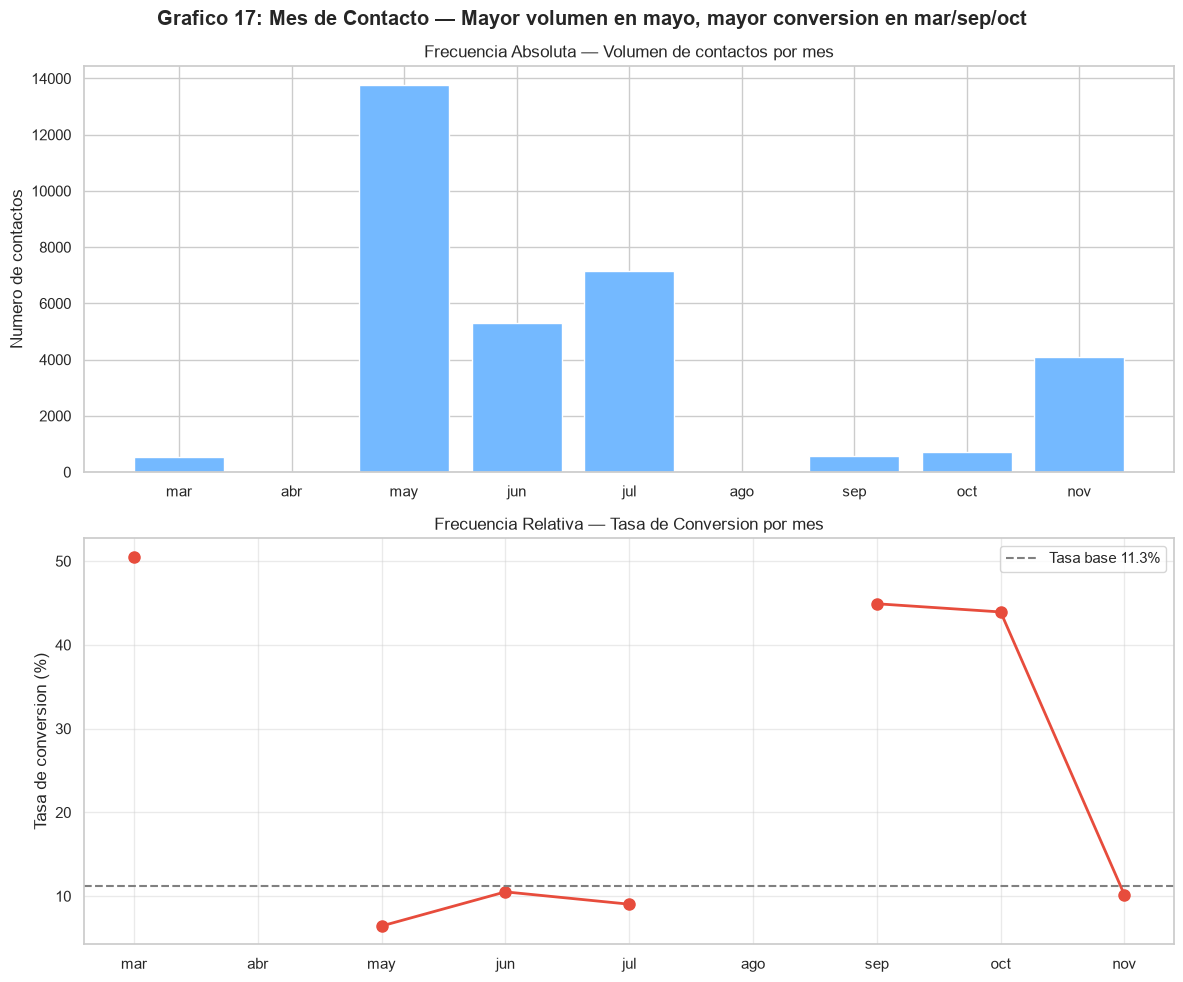

In [19]:
order_months = ['mar','abr','may','jun','jul','ago','sep','oct','nov','dic']
conv_mes = df.groupby('mes')['deposito_plazo_num'].mean().reindex(order_months)*100
vol_mes = df.groupby('mes')['deposito_plazo_num'].count().reindex(order_months)
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
axes[0].bar(vol_mes.index, vol_mes.values, color='#74b9ff', edgecolor='white')
axes[0].set_ylabel('Numero de contactos')
axes[0].set_title('Frecuencia Absoluta — Volumen de contactos por mes')
axes[1].plot(conv_mes.index, conv_mes.values, marker='o', color='#e74c3c', linewidth=2, markersize=8)
tasa_base = df['deposito_plazo_num'].mean()*100
axes[1].axhline(tasa_base, color='gray', linestyle='--', label='Tasa base '+str(round(tasa_base,1))+'%')
axes[1].set_ylabel('Tasa de conversion (%)')
axes[1].set_title('Frecuencia Relativa — Tasa de Conversion por mes')
axes[1].legend()
axes[1].grid(True, alpha=0.4)
plt.suptitle('Grafico 17: Mes de Contacto — Mayor volumen en mayo, mayor conversion en mar/sep/oct', fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/bivariado_mes_conversion.png', bbox_inches='tight', dpi=150)
plt.show()

### Grafico 18: Tasa Euribor vs Conversion

Al cruzar la tasa de interés con el éxito de la campaña, evidenciamos que un entorno de tasas bajas favorece significativamente la contratación de depósitos.


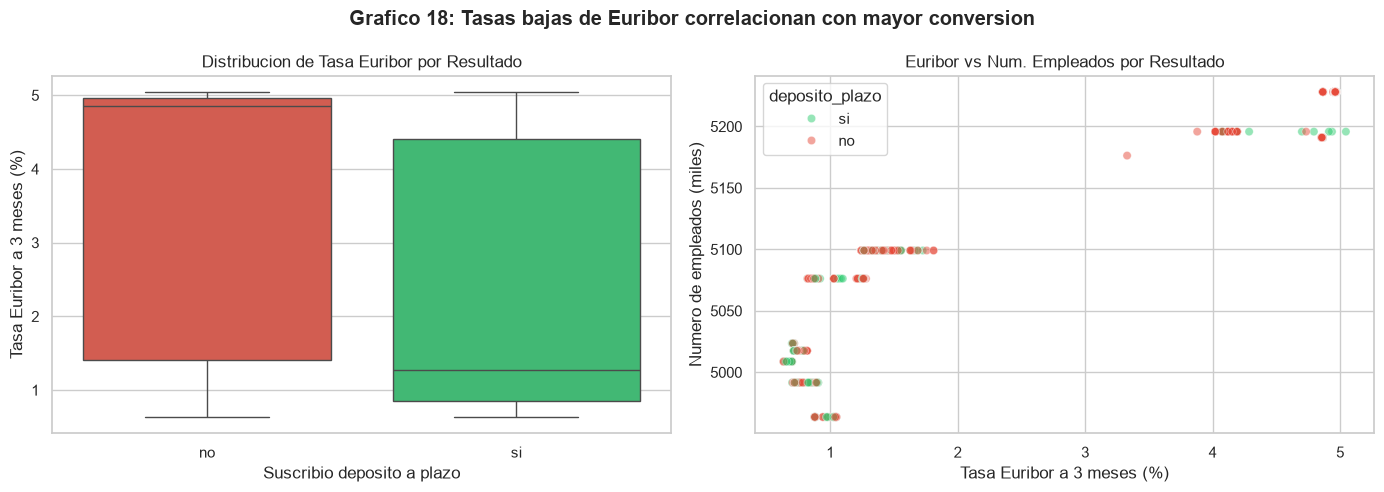

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette_dep = {'si':'#2ecc71','no':'#e74c3c'}
sns.boxplot(data=df, x='deposito_plazo', y='tasa_euribor', palette=palette_dep, ax=axes[0])
axes[0].set_xlabel('Suscribio deposito a plazo')
axes[0].set_ylabel('Tasa Euribor a 3 meses (%)')
axes[0].set_title('Distribucion de Tasa Euribor por Resultado')
sns.scatterplot(data=df.sample(3000, random_state=42), x='tasa_euribor', y='num_empleados',
                hue='deposito_plazo', palette=palette_dep, alpha=0.5, ax=axes[1])
axes[1].set_xlabel('Tasa Euribor a 3 meses (%)')
axes[1].set_ylabel('Numero de empleados (miles)')
axes[1].set_title('Euribor vs Num. Empleados por Resultado')
plt.suptitle('Grafico 18: Tasas bajas de Euribor correlacionan con mayor conversion', fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/bivariado_tasa_euribor_conversion.png', bbox_inches='tight', dpi=150)
plt.show()

### Grafico 19: Numero de Contactos en Campana vs Conversion

Evalúa el impacto de la insistencia. Muestra cómo la probabilidad de éxito decae drásticamente después de los primeros intentos de contacto.


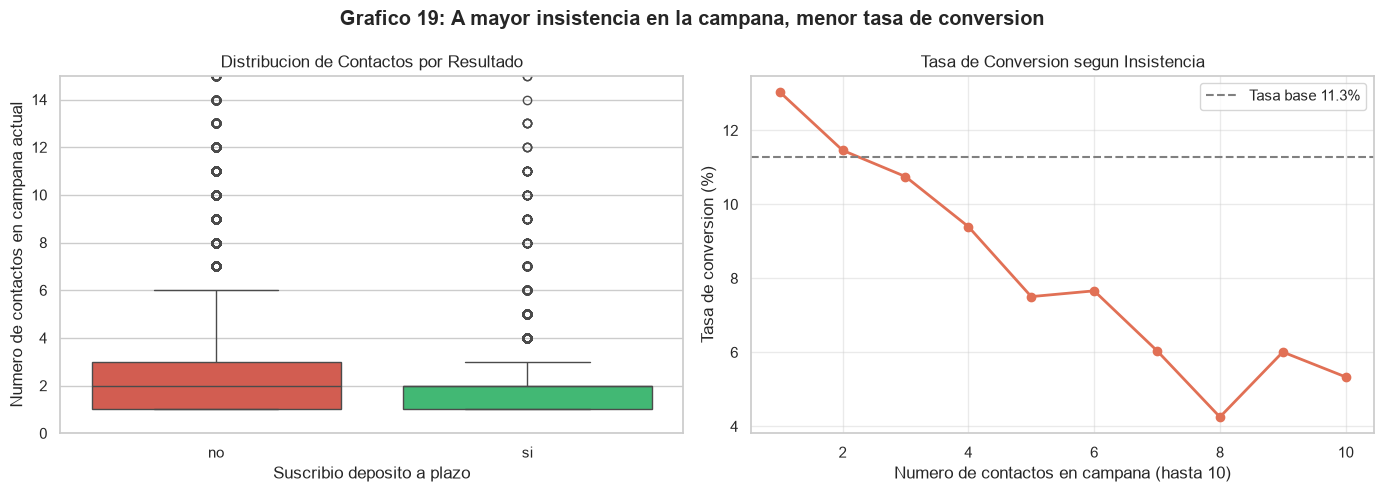

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette_dep = {'si':'#2ecc71','no':'#e74c3c'}
sns.boxplot(data=df, x='deposito_plazo', y='campana', palette=palette_dep, ax=axes[0])
axes[0].set_ylim(0, 15)
axes[0].set_xlabel('Suscribio deposito a plazo')
axes[0].set_ylabel('Numero de contactos en campana actual')
axes[0].set_title('Distribucion de Contactos por Resultado')
conv_campana = df[df['campana']<=10].groupby('campana')['deposito_plazo_num'].mean()*100
axes[1].plot(conv_campana.index, conv_campana.values, marker='o', color='#e17055', linewidth=2)
tasa_base = df['deposito_plazo_num'].mean()*100
axes[1].axhline(tasa_base, color='gray', linestyle='--', label='Tasa base '+str(round(tasa_base,1))+'%')
axes[1].set_xlabel('Numero de contactos en campana (hasta 10)')
axes[1].set_ylabel('Tasa de conversion (%)')
axes[1].set_title('Tasa de Conversion segun Insistencia')
axes[1].legend()
axes[1].grid(True, alpha=0.4)
plt.suptitle('Grafico 19: A mayor insistencia en la campana, menor tasa de conversion', fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/bivariado_campana_conversion.png', bbox_inches='tight', dpi=150)
plt.show()

### Grafico 20: Historial Previo de Contacto vs Conversion

Confirma que el simple hecho de haber contactado al cliente antes (independientemente del resultado) mejora la receptividad en comparación con los clientes totalmente nuevos.


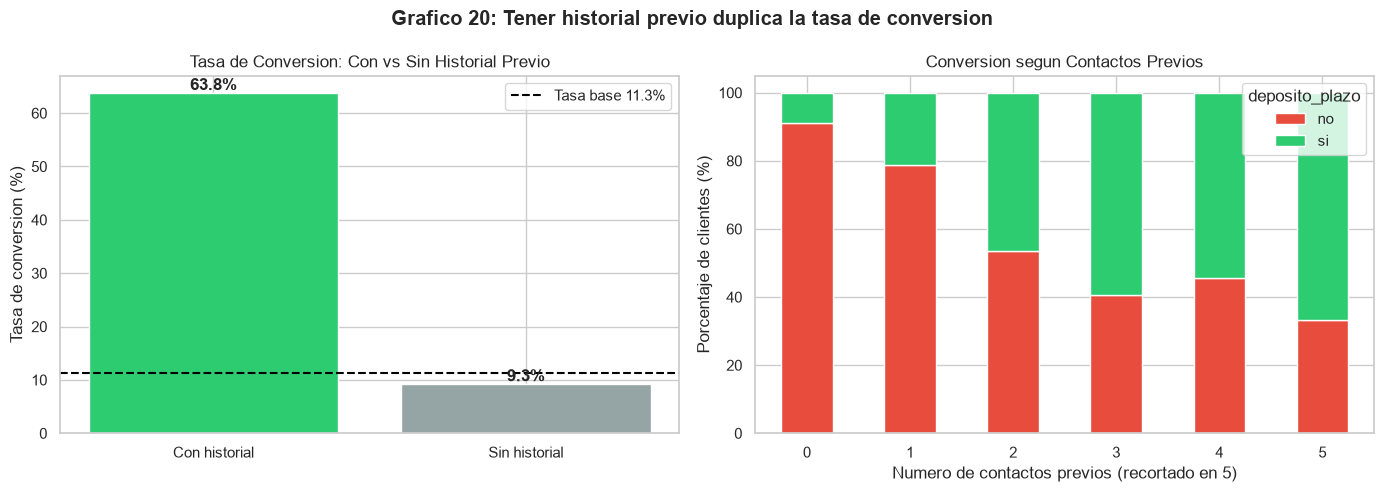

In [22]:
df['fue_contactado'] = (df['dias_previos']!=999).map({True:'Con historial',False:'Sin historial'})
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
conv_hist = df.groupby('fue_contactado')['deposito_plazo_num'].mean()*100
colores_hist = ['#2ecc71','#95a5a6']
bars = axes[0].bar(conv_hist.index, conv_hist.values, color=colores_hist, edgecolor='white')
for bar, val in zip(bars, conv_hist.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 str(round(val,1))+'%', ha='center', fontweight='bold', fontsize=12)
tasa_base = df['deposito_plazo_num'].mean()*100
axes[0].axhline(tasa_base, color='black', linestyle='--', label='Tasa base '+str(round(tasa_base,1))+'%')
axes[0].set_ylabel('Tasa de conversion (%)')
axes[0].set_title('Tasa de Conversion: Con vs Sin Historial Previo')
axes[0].legend()
prev_res = pd.crosstab(df['anterior'].clip(0,5), df['deposito_plazo'], normalize='index')*100
prev_res.plot(kind='bar', stacked=True, color=['#e74c3c','#2ecc71'], ax=axes[1], edgecolor='white')
axes[1].set_xlabel('Numero de contactos previos (recortado en 5)')
axes[1].set_ylabel('Porcentaje de clientes (%)')
axes[1].set_title('Conversion segun Contactos Previos')
axes[1].tick_params(axis='x', rotation=0)
plt.suptitle('Grafico 20: Tener historial previo duplica la tasa de conversion', fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/bivariado_historial_previo_conversion.png', bbox_inches='tight', dpi=150)
plt.show()

## 3. Analisis Multivariado

Análisis de las relaciones conjuntas entre múltiples variables simultáneamente. En particular, la evaluación de la **multicolinealidad** es un paso crítico en la preparación de datos. Cuando dos o más variables predictoras explican exactamente el mismo fenómeno (están altamente correlacionadas entre sí), introducir ambas en un modelo incrementa innecesariamente la complejidad y puede desestabilizar los pesos asignados por algoritmos lineales, reduciendo su capacidad de generalización.


### Grafico 21: Matriz de Correlacion Spearman — Variables Numericas

Esta matriz detecta redundancias entre nuestras variables numéricas. Es fundamental para evitar inyectar información duplicada que confunda al algoritmo de Machine Learning.


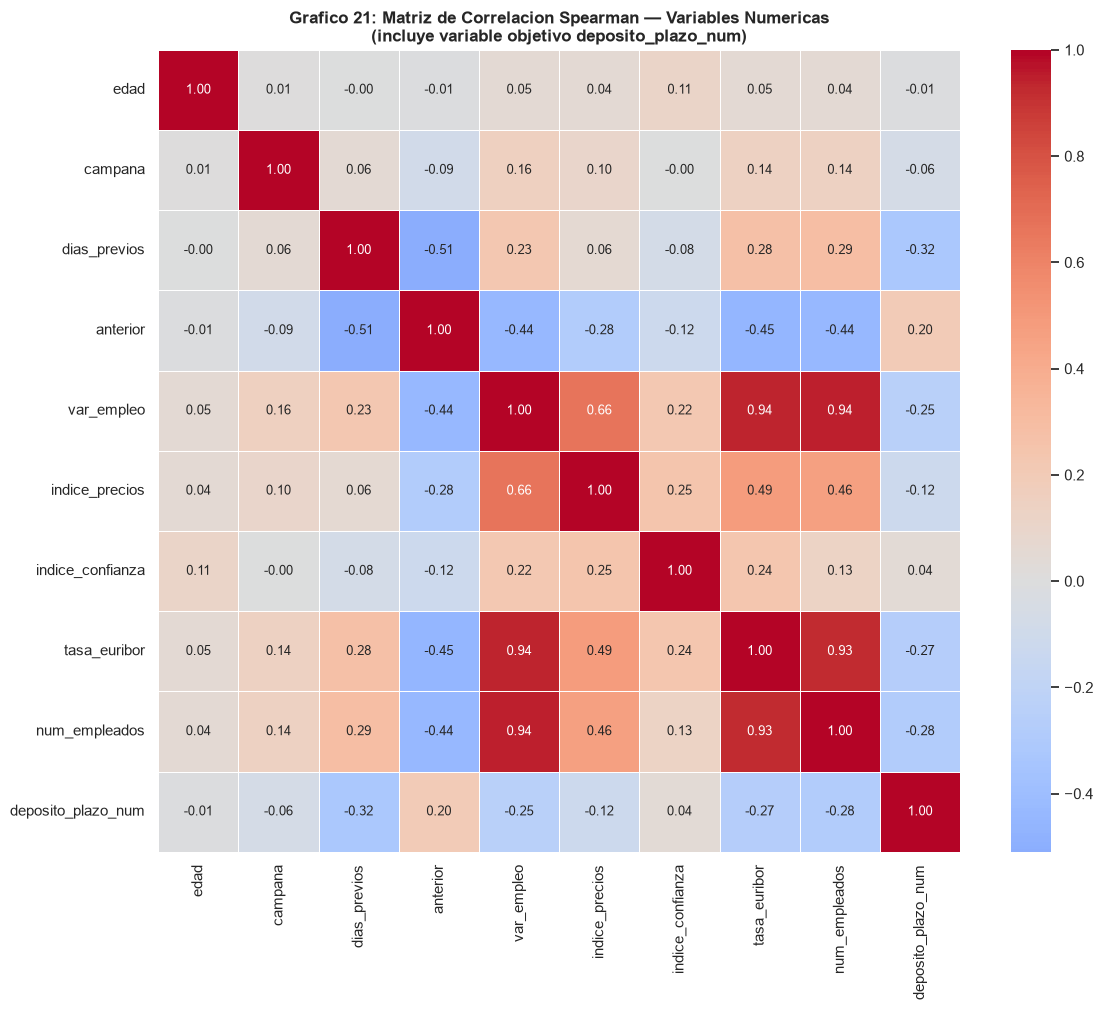

Nota: Las variables macroeconomicas muestran alta multicolinealidad entre si.


In [23]:
num_cols_corr = ['edad','campana','dias_previos','anterior',
                 'var_empleo','indice_precios','indice_confianza','tasa_euribor',
                 'num_empleados','deposito_plazo_num']
corr_matrix = df[num_cols_corr].corr(method='spearman')
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, linewidths=0.5, annot_kws={'size':9}, square=True)
ax.set_title('Grafico 21: Matriz de Correlacion Spearman — Variables Numericas\n'
             '(incluye variable objetivo deposito_plazo_num)', fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/multivariado_correlacion_spearman.png', bbox_inches='tight', dpi=150)
plt.show()
print('Nota: Las variables macroeconomicas muestran alta multicolinealidad entre si.')

### Grafico 22: Multicolinealidad — Variables Macroeconomicas

Profundiza en la alta correlación entre los indicadores económicos, justificando por qué algunos modelos más sensibles podrían requerir que eliminemos indicadores redundantes.


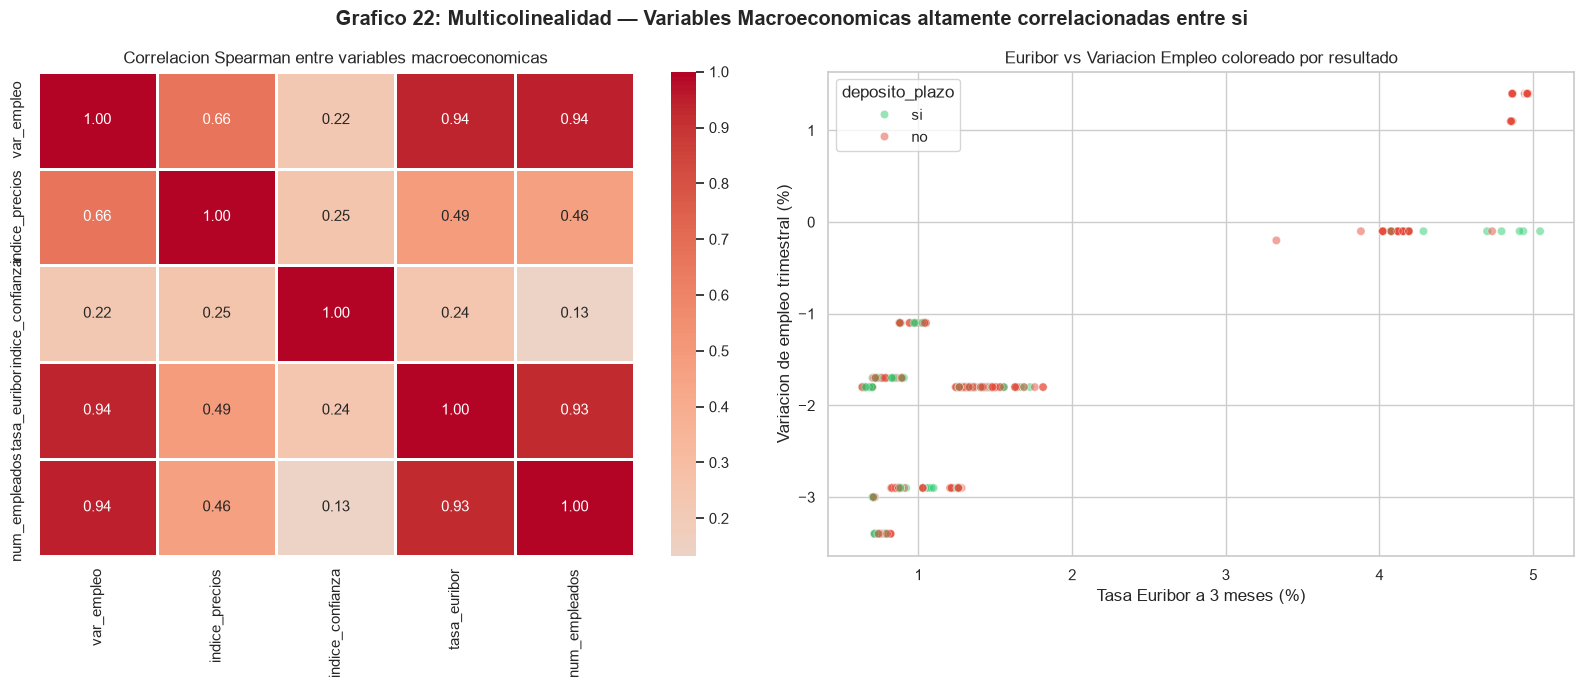

In [24]:
macro = ['var_empleo','indice_precios','indice_confianza','tasa_euribor','num_empleados']
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.heatmap(df[macro].corr(method='spearman'), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[0], linewidths=1, annot_kws={'size':11})
axes[0].set_title('Correlacion Spearman entre variables macroeconomicas')
sns.scatterplot(data=df.sample(3000, random_state=42), x='tasa_euribor', y='var_empleo',
                hue='deposito_plazo', palette={'si':'#2ecc71','no':'#e74c3c'},
                alpha=0.5, ax=axes[1])
axes[1].set_xlabel('Tasa Euribor a 3 meses (%)')
axes[1].set_ylabel('Variacion de empleo trimestral (%)')
axes[1].set_title('Euribor vs Variacion Empleo coloreado por resultado')
plt.suptitle('Grafico 22: Multicolinealidad — Variables Macroeconomicas altamente correlacionadas entre si', fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/multivariado_multicolinealidad_macroeconomica.png', bbox_inches='tight', dpi=150)
plt.show()

## 4. Pipeline de Preprocesamiento para Machine Learning

Preparacion del dataset para un hipotetico modelo de clasificacion. Se documentan los pasos sin entrenar modelos.

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

print('Iniciando Pipeline de Preprocesamiento para Machine Learning')
print('='*55)
df_ml = df.copy()


Iniciando Pipeline de Preprocesamiento para Machine Learning


### 4.1 Tratamiento de Datos Faltantes
Al examinar las variables categóricas principales (como `trabajo`, `estado_civil`, `educacion`, `mora`, `vivienda`, `prestamo`), se detectó la presencia recurrente del valor `"desconocido"`, el cual opera funcionalmente como un dato nulo o faltante encubierto. 

Tomar la decisión de eliminar todas las filas que contienen datos desconocidos resultaría en una merma significativa del tamaño de la muestra, con el riesgo inherente de sesgar el aprendizaje del modelo (perdiendo perfiles específicos de clientes). Por lo tanto, se emplea la técnica de **imputación por la moda**. Al rellenar estos vacíos con la categoría estadísticamente más frecuente de cada columna respectiva, se logra salvaguardar la integridad de la base de datos sin distorsionar groseramente la distribución original de las clases dominantes, permitiendo así que las funciones matemáticas de los algoritmos operen de manera ininterrumpida.


In [26]:
# Paso 1: Imputacion de valores desconocidos por moda
cols_unknown = ['trabajo','estado_civil','educacion','mora','vivienda','prestamo']
for col in cols_unknown:
    if 'desconocido' in df_ml[col].values:
        moda = df_ml[df_ml[col]!='desconocido'][col].mode()[0]
        n = (df_ml[col]=='desconocido').sum()
        df_ml[col] = df_ml[col].replace('desconocido', moda)
        print(f'Paso 1 - {col}: {n} valores imputados con moda = {moda}')


Paso 1 - trabajo: 330 valores imputados con moda = administrativo
Paso 1 - estado_civil: 80 valores imputados con moda = casado
Paso 1 - educacion: 1730 valores imputados con moda = universitario
Paso 1 - mora: 8596 valores imputados con moda = no
Paso 1 - vivienda: 990 valores imputados con moda = si
Paso 1 - prestamo: 990 valores imputados con moda = no


### 4.2 Ingeniería de Características y Tratamiento de Valores Atípicos (Outliers)

El perfeccionamiento del conjunto de datos implica ajustes tanto en su limpieza extrema como en la creación de nuevos aportes de valor (Feature Engineering):

1. **Tratamiento de Outliers:** Los valores extremos detectados en campos como `edad` y duración de la `campana` poseen el potencial de arrastrar las estimaciones promedio y deteriorar el ajuste de curvas en modelos de regresión. Aplicar *Capping* utilizando el límite del Rango Intercuartílico (IQR) suaviza estas anomalías, encapsulándolas en los umbrales máximos tolerables sin perder la observación completa.

2. **Nuevas Variables Enriquecidas:** Basándose directamente en los descubrimientos del análisis exploratorio, se sintetizan nuevas características orientadas a maximizar la exactitud de predicción del modelo:
    *   **`grupo_etario`**: Al evidenciar en los gráficos bivariados que la respuesta de conversión no guarda una relación lineal estricta con la edad (los adultos mayores presentan un ratio excepcionalmente alto), binarizar y categorizar esta métrica en tramos etarios ayuda a los algoritmos basados en árboles de decisión a realizar divisiones (splits) mucho más limpias.
    *   **`fue_contactado_antes`**: La exploración determinó que el historial de acercamientos previos correlaciona masivamente con el éxito de una nueva campaña. Esta variable condensa ese impacto de forma binaria e instantánea.
    *   **`euribor_alto`**: Agrupa la adversidad económica bajo una señal unificada (>3%), dotando al algoritmo de un atajo para decodificar contextos macroeconómicos hostiles.


In [27]:
# Paso 2A: Capping de outliers con IQR
def cap_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return series.clip(lower=Q1-1.5*IQR, upper=Q3+1.5*IQR)

df_ml['edad'] = cap_outliers(df_ml['edad'])
df_ml['campana'] = cap_outliers(df_ml['campana'])
print('Paso 2A - Outliers capeados en edad y campana usando IQR')

# Paso 2B: Creacion de Nuevas Variables (Feature Engineering)
# 1. Grupo Etario
bins = [0, 30, 60, 100]
labels = ['Joven', 'Adulto', 'Mayor']
df_ml['grupo_etario'] = pd.cut(df_ml['edad'], bins=bins, labels=labels)

# 2. Fue contactado antes (999 significa nunca contactado)
df_ml['fue_contactado_antes'] = (df_ml['dias_previos'] != 999).astype(int)

# 3. Euribor alto (mayor a 3%)
df_ml['euribor_alto'] = (df_ml['tasa_euribor'] > 3.0).astype(int)

print('Paso 2B - Creadas nuevas variables: grupo_etario, fue_contactado_antes, euribor_alto')


Paso 2A - Outliers capeados en edad y campana usando IQR
Paso 2B - Creadas nuevas variables: grupo_etario, fue_contactado_antes, euribor_alto


### 4.3 Codificación de Variables Categóricas (Encoding)

Dado que las arquitecturas de Machine Learning están diseñadas para procesar exclusivamente estructuras numéricas, es mandatorio traducir todo el texto descriptivo sin inducir al modelo a cometer errores de interpretación semántica. Para esto se emplea una estrategia mixta:

*   **Ordinal Encoding:** Esta técnica se reserva en exclusiva para la variable `educacion`. El nivel educativo humano posee intrínsecamente un orden lógico y evolutivo (donde educación básica precede a la educación universitaria). Transformar esto a una escala numérica secuencial (1 al 7) habilita al modelo para entender y aprovechar esta progresión natural.
*   **One-Hot Encoding (`get_dummies`):** Para todo el espectro de variables netamente nominales (como `estado_civil` o sector de `trabajo`), la aplicación de una codificación ordinal inyectaría una ilusión de jerarquía inexistente. Crear columnas binarias independientes para cada categoría asegura un trato neutral por parte del modelo estadístico, tratando a los casados y a los solteros como vectores ortogonales en vez de puntos distanciados en una misma recta.


In [28]:
# Paso 3A: Ordinal Encoding para variables con jerarquia
orden_edu_map = {
    'analfabeto': 1, 'basica_4': 2, 'basica_6': 3, 
    'basica_9': 4, 'media': 5, 'tecnico_prof': 6, 'universitario': 7
}
df_ml['educacion_ordinal'] = df_ml['educacion'].map(orden_edu_map)
df_ml = df_ml.drop('educacion', axis=1) # Se elimina la original
print('Paso 3A - Ordinal Encoding aplicado a: educacion')

# Paso 3B: One-Hot Encoding para variables sin jerarquia
cat_cols_ml = df_ml.select_dtypes(include=['object', 'category']).columns.drop('deposito_plazo', errors='ignore').tolist()
n_antes = df_ml.shape[1]
df_ml = pd.get_dummies(df_ml, columns=cat_cols_ml, drop_first=True)
bool_cols = df_ml.select_dtypes(include=['bool']).columns
df_ml[bool_cols] = df_ml[bool_cols].astype(int)
print(f'Paso 3B - OHE: Dataset paso de {n_antes} a {df_ml.shape[1]} columnas')


Paso 3A - Ordinal Encoding aplicado a: educacion
Paso 3B - OHE: Dataset paso de 26 a 52 columnas


### 4.4 Normalización y Estandarización de Variables Numéricas

El conjunto de datos final alberga métricas que coexisten en universos de escala diametralmente opuestos. Mientras que la tasa del euribor fluctúa entre valores de un solo dígito, el conteo de empleados corporativos oscila en los cinco miles. Suministrar esta información en bruto a un estimador penalizaría injustamente a las variables de escala menor; el modelo interpretaría matemáticamente que un cambio de mil empleados es muchísimo más crítico que un salto de cinco puntos porcentuales de interés.

La aplicación de **StandardScaler** neutraliza esta asimetría. Al re-escalar todas las dimensiones numéricas para forzar una media de cero y una desviación típica de uno, se logra que el peso geométrico de cada característica dependa exclusivamente de su correlación con la variable objetivo y no de su arbitraria unidad de medida original.

A continuación, se demuestra visualmente el efecto igualador de esta técnica transformando tres métricas con magnitudes previamente incompatibles:


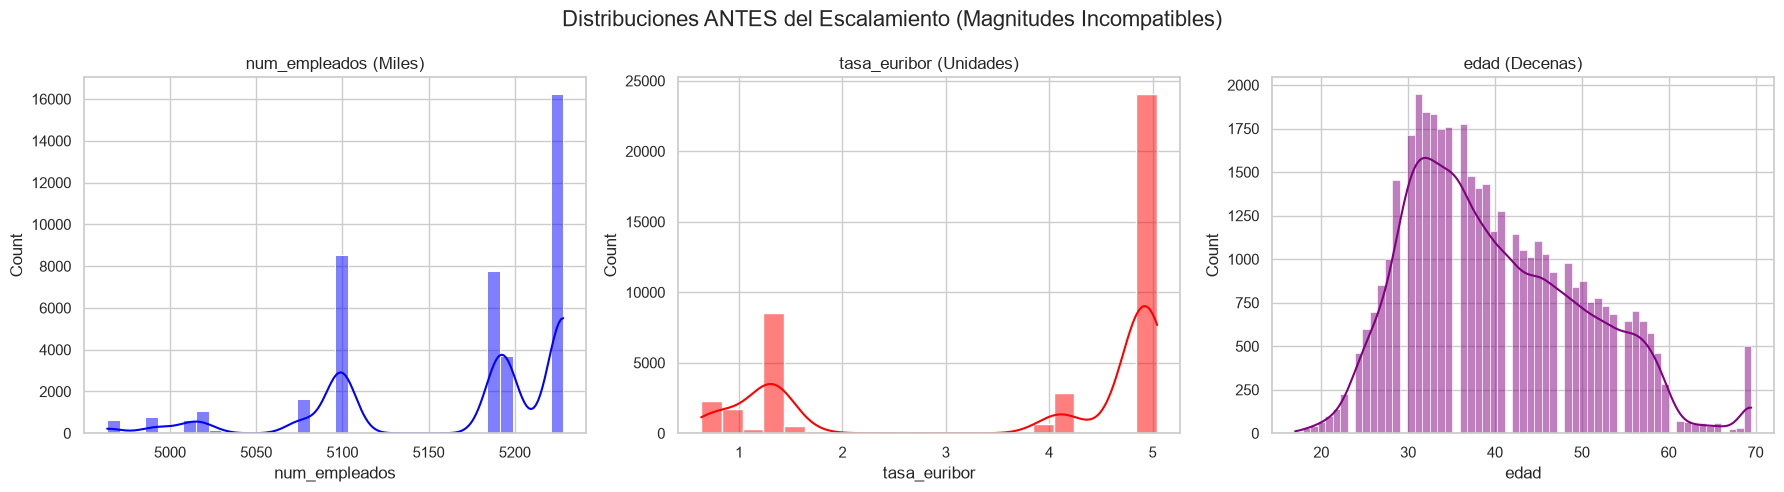

Paso 4 - StandardScaler aplicado a variables numericas


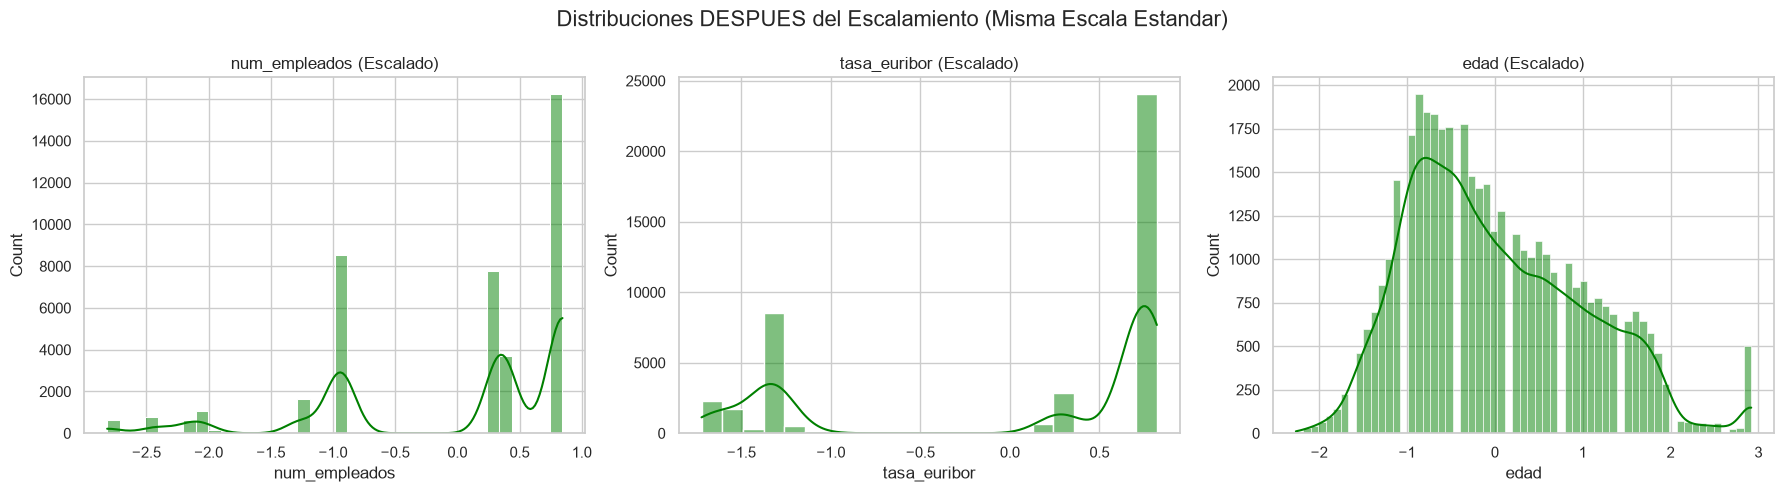

In [29]:
# Variables a estandarizar
num_cols_ml = ['edad','campana','dias_previos','anterior',
               'var_empleo','indice_precios','indice_confianza','tasa_euribor','num_empleados']

# Visualizacion ANTES del escalamiento (Panel Comparativo)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df_ml['num_empleados'], kde=True, color='blue', ax=axes[0]).set_title('num_empleados (Miles)')
sns.histplot(df_ml['tasa_euribor'], kde=True, color='red', ax=axes[1]).set_title('tasa_euribor (Unidades)')
sns.histplot(df_ml['edad'], kde=True, color='purple', ax=axes[2]).set_title('edad (Decenas)')
fig.suptitle('Distribuciones ANTES del Escalamiento (Magnitudes Incompatibles)', fontsize=16)
plt.tight_layout()
plt.savefig('graficos/preprocesamiento_escalamiento_antes.png', bbox_inches='tight', dpi=150)
plt.show()

# Paso 4: StandardScaler
scaler = StandardScaler()
df_ml[num_cols_ml] = scaler.fit_transform(df_ml[num_cols_ml])
print('Paso 4 - StandardScaler aplicado a variables numericas')

# Visualizacion DESPUES del escalamiento (Panel Comparativo)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df_ml['num_empleados'], kde=True, color='green', ax=axes[0]).set_title('num_empleados (Escalado)')
sns.histplot(df_ml['tasa_euribor'], kde=True, color='green', ax=axes[1]).set_title('tasa_euribor (Escalado)')
sns.histplot(df_ml['edad'], kde=True, color='green', ax=axes[2]).set_title('edad (Escalado)')
fig.suptitle('Distribuciones DESPUES del Escalamiento (Misma Escala Estandar)', fontsize=16)
plt.tight_layout()
plt.savefig('graficos/preprocesamiento_escalamiento_despues.png', bbox_inches='tight', dpi=150)
plt.show()


In [30]:
print(f'Dataset listo para ML: {df_ml.shape[0]:,} filas x {df_ml.shape[1]} columnas')
print(f'Variable objetivo: deposito_plazo_num (1=si, 0=no)')
print(f'Desbalanceo: {df_ml["deposito_plazo_num"].value_counts().to_dict()}')


Dataset listo para ML: 41,176 filas x 52 columnas
Variable objetivo: deposito_plazo_num (1=si, 0=no)
Desbalanceo: {0: 36537, 1: 4639}


## 5. Conclusiones

### Es posible crear un modelo predictivo?
Si. Las variables muestran correlaciones significativas con la variable objetivo. Las mas relevantes son: `tasa_euribor`, `num_empleados`, `resultado_anterior`, `dias_previos`, `var_empleo`.

### Que caracteriza a un cliente que contrata un deposito a plazo?
- **Exito en campana anterior:** Conversion del 63.8% vs 11.3% de la tasa base.
- **Contexto economico favorable:** Tasas Euribor bajas (< 2%) coinciden con mayor conversion.
- **Con historial de contacto:** Clientes contactados previamente tienen doble de probabilidad.
- **Perfil demografico:** Jubilados y estudiantes muestran las mayores tasas de conversion.
- **Insistencia contraproducente:** Mas contactos en la campana actual = menor conversion.

### Variables descartadas
- `duration` (duracion de la llamada): eliminada por ser **data leaker** — solo se conoce al final de la llamada, no puede usarse para predecir.

### Contexto economico
Las variables macroeconomicas son los predictores mas fuertes pero presentan **alta multicolinealidad**. En un modelo real se recomienda retener solo `tasa_euribor` o aplicar PCA sobre el grupo macroeconomico.

## 6. Referencias y Bibliografía

1. **Scikit-learn Developers. (2024).** *Preprocessing data.* Scikit-learn Documentation. Recuperado de [https://scikit-learn.org/stable/modules/preprocessing.html](https://scikit-learn.org/stable/modules/preprocessing.html)
2. **Pandas Development Team. (2024).** *pandas.get_dummies.* Pandas Documentation. Recuperado de [https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html)
3. **Hunter, J. D. (2007).** *Matplotlib: A 2D graphics environment.* Computing in Science & Engineering, 9(3), 90-95. Recuperado de [https://matplotlib.org/](https://matplotlib.org/)
4. **Waskom, M. L. (2021).** *Seaborn: statistical data visualization.* Journal of Open Source Software, 6(60), 3021. Recuperado de [https://seaborn.pydata.org/](https://seaborn.pydata.org/)
5. **Harris, C. R., et al. (2020).** *Array programming with NumPy.* Nature, 585(7825), 357-362. Recuperado de [https://numpy.org/](https://numpy.org/)